# Credit Card Fraud Detection

Kelly Wu

<hr>

## 1. Introduction

**Dataset introduction:** This dataset contains 284,807 real credit card transactions made by European cardholders over two days in September 2013 (the ULB Credit Card Fraud Detection dataset). Only 492 of these transactions (0.17%) are fraudulent. Because the original transaction details are sensitive, the 28 numeric features (`V1`–`V28`) are PCA-transformed versions of the real features, anonymized, but still preserving the underlying patterns a model can learn from.

**Research question:** Can we build a classifier that reliably flags fraudulent transactions, and how do different models trade off *catching fraud* against *falsely flagging legitimate transactions*?

**Response variable:** `Class` (1 = fraud, 0 = legitimate).

**Contextual importance:** A bank needs to flag likely fraud before money is lost, but flagging too aggressively means blocking real customers' legitimate purchases, a real cost, not a free action. This project compares three models specifically to make that tradeoff visible, rather than just reporting one accuracy number.

In [2]:
import sys
!{sys.executable} -m pip install xgboost


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


## 2. Loading and Exploring the Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

df = pd.read_csv("data/creditcard.csv")
df.shape

(284807, 31)

In [4]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

Only 492 of 284,807 transactions are fraud, a 0.17% fraud rate. This matters a lot for how we evaluate models later: a model that predicts "not fraud" for every single transaction would score **99.83% accuracy** while catching zero fraud. Accuracy alone can't be trusted here.

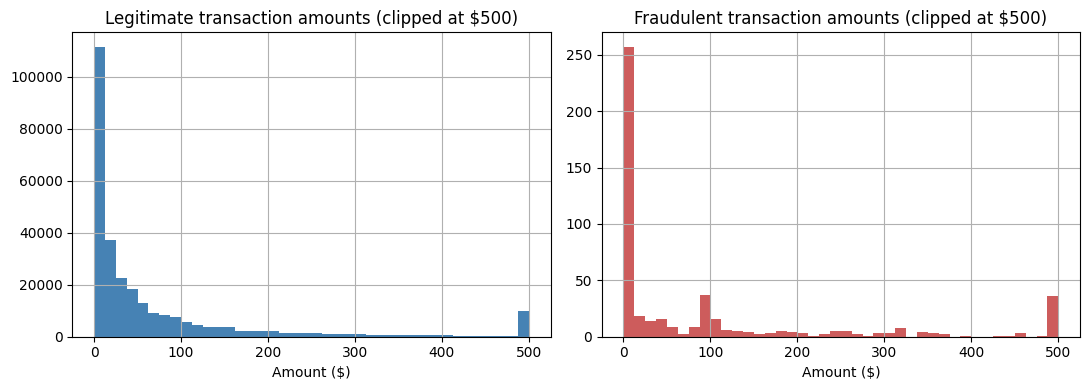

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df[df.Class==0]["Amount"].clip(upper=500).hist(bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("Legitimate transaction amounts (clipped at $500)")
axes[0].set_xlabel("Amount ($)")

df[df.Class==1]["Amount"].clip(upper=500).hist(bins=40, ax=axes[1], color="indianred")
axes[1].set_title("Fraudulent transaction amounts (clipped at $500)")
axes[1].set_xlabel("Amount ($)")
plt.tight_layout()
plt.show()

Fraudulent transactions skew toward smaller amounts than the full legitimate distribution, though both distributions have a long tail. This alone isn't a strong enough pattern to catch fraud by amount alone, which is exactly why a full classifier using all 28 anonymized features is needed rather than a simple amount threshold.

## 3. SQL Exploration

Rather than only using pandas, the data is also loaded into SQLite to demonstrate SQL specifically: window functions and a CTE, not just basic queries against a single table.

The data spans only two real days (~48 hours), so an **hourly** summary table gives more useful granularity than a daily one would.

In [6]:
df["hour"] = (df["Time"] // 3600).astype(int)

conn = sqlite3.connect("data/fraud.db")
df.to_sql("transactions", conn, if_exists="replace", index=False)

hourly = df.groupby("hour").agg(
    n_transactions=("Class", "count"),
    n_fraud=("Class", "sum"),
    avg_amount=("Amount", "mean"),
).reset_index()
hourly["fraud_rate"] = hourly["n_fraud"] / hourly["n_transactions"]
hourly.to_sql("hourly_summary", conn, if_exists="replace", index=False)
hourly.head()

,hour,n_transactions,n_fraud,avg_amount,fraud_rate
0,0,3963,2,64.875566,0.000505
1,1,2217,2,65.902431,0.000902
2,2,1576,21,69.047697,0.013325
3,3,1821,13,51.788490,0.007139
4,4,1082,6,73.789852,0.005545


### Window function: rolling 3-hour average fraud rate

In [7]:
pd.read_sql('''
    SELECT hour, fraud_rate,
    AVG(fraud_rate) OVER (ORDER BY hour ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) as rolling_3hr_avg
    FROM hourly_summary ORDER BY hour LIMIT 10
''', conn)

,hour,fraud_rate,rolling_3hr_avg
0,0,0.000505,0.000505
1,1,0.000902,0.000703
2,2,0.013325,0.004911
3,3,0.007139,0.007122
4,4,0.005545,0.008670
5,5,0.006544,0.006409
6,6,0.001638,0.004576
7,7,0.006829,0.005004
8,8,0.000965,0.003144
9,9,0.001904,0.003233


### Window function: ranking each fraud case's amount within its own hour

In [8]:
pd.read_sql('''
    SELECT hour, Amount, Class,
    RANK() OVER (PARTITION BY hour ORDER BY Amount DESC) as amount_rank_in_hour
    FROM transactions WHERE Class = 1 ORDER BY hour, amount_rank_in_hour LIMIT 10
''', conn)

,hour,Amount,Class,amount_rank_in_hour
0,0,529.00,1,1
1,0,0.00,1,2
2,1,239.93,1,1
3,1,59.00,1,2
4,2,1809.68,1,1
5,2,1.10,1,2
6,2,1.00,1,3
7,2,1.00,1,3
8,2,1.00,1,3
9,2,1.00,1,3


### CTE: which hours had unusually high fraud rates?

In [9]:
pd.read_sql('''
    WITH overall AS (
        SELECT AVG(fraud_rate) as avg_fraud_rate FROM hourly_summary
    )
    SELECT h.hour, h.n_transactions, h.n_fraud, ROUND(h.fraud_rate, 4) as fraud_rate,
    ROUND(o.avg_fraud_rate, 4) as overall_avg_fraud_rate
    FROM hourly_summary h, overall o
    WHERE h.fraud_rate > 3 * o.avg_fraud_rate
    ORDER BY h.fraud_rate DESC LIMIT 10
''', conn)

,hour,n_transactions,n_fraud,fraud_rate,overall_avg_fraud_rate
0,26,1752,36,0.0205,0.0027
1,28,1127,17,0.0151,0.0027
2,2,1576,21,0.0133,0.0027


**Finding:** Hour 26 had a fraud rate of 2.05%, roughly **7.6x** the overall average of 0.27%. That's a genuinely useful signal suggesting time-of-day/session context matters, even though the current models below don't yet use `hour` as a feature (noted as future work).

## 4. Classification: Comparing Three Models

**Research question:** Which classifier (logistic regression, random forest, or XGBoost) best identifies fraud, and what does "best" actually mean once precision and recall are considered instead of accuracy?

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["Class", "hour"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=313, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train.shape, X_test.shape

((227845, 30), (56962, 30))

### Model 1: Logistic Regression

`class_weight='balanced'` is used since, without adjusting for the 0.17% fraud rate, logistic regression would mostly just learn to predict 'not fraud'.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

log_model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=313)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)
log_proba = log_model.predict_proba(X_test_scaled)[:, 1]

print("Precision:", round(precision_score(y_test, log_pred), 3))
print("Recall:   ", round(recall_score(y_test, log_pred), 3))
print("F1:       ", round(f1_score(y_test, log_pred), 3))
print("ROC-AUC:  ", round(roc_auc_score(y_test, log_proba), 3))
print("Confusion matrix:\n", confusion_matrix(y_test, log_pred))

Precision: 0.066
Recall:    0.929
F1:        0.123
ROC-AUC:   0.977
Confusion matrix:
 [[55568  1296]
 [    7    91]]


Logistic regression catches 92.9% of fraud (recall), but only 6.6% of its fraud *flags* are actually fraud (precision). In this test set alone, it flagged 1,296 legitimate transactions to catch 91 real fraud cases.

### Model 2: Random Forest

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=313, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("Precision:", round(precision_score(y_test, rf_pred), 3))
print("Recall:   ", round(recall_score(y_test, rf_pred), 3))
print("F1:       ", round(f1_score(y_test, rf_pred), 3))
print("ROC-AUC:  ", round(roc_auc_score(y_test, rf_proba), 3))
print("Confusion matrix:\n", confusion_matrix(y_test, rf_pred))

Precision: 0.931
Recall:    0.827
F1:        0.876
ROC-AUC:   0.963
Confusion matrix:
 [[56858     6]
 [   17    81]]


Random forest is the opposite extreme from logistic regression: only 6 false positives in the entire test set, but it misses more real fraud (82.7% recall vs. logistic regression's 92.9%).

### Model 3: XGBoost

In [13]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(n_estimators=100, scale_pos_weight=scale_pos_weight, random_state=313, eval_metric="logloss")
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print("Precision:", round(precision_score(y_test, xgb_pred), 3))
print("Recall:   ", round(recall_score(y_test, xgb_pred), 3))
print("F1:       ", round(f1_score(y_test, xgb_pred), 3))
print("ROC-AUC:  ", round(roc_auc_score(y_test, xgb_proba), 3))
print("Confusion matrix:\n", confusion_matrix(y_test, xgb_pred))

Precision: 0.885
Recall:    0.867
F1:        0.876
ROC-AUC:   0.977
Confusion matrix:
 [[56853    11]
 [   13    85]]


### Feature importance (XGBoost)

Which of the anonymized `V1`-`V28` features mattered most for catching fraud?

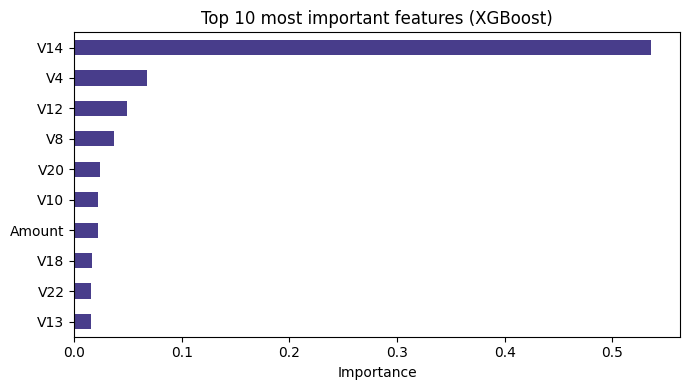

In [14]:
importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)
importances.plot(kind="barh", figsize=(7,4), color="darkslateblue")
plt.gca().invert_yaxis()
plt.title("Top 10 most important features (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 5. Model Comparison and Business Recommendation

| Model | Precision | Recall | F1 | ROC-AUC | False Positives | False Negatives |
|---|---|---|---|---|---|---|
| Logistic Regression | 0.066 | 0.929 | 0.123 | 0.977 | 1,296 | 7 |
| Random Forest | 0.931 | 0.827 | 0.876 | 0.963 | 6 | 17 |
| XGBoost | 0.885 | 0.867 | 0.876 | 0.977 | 11 | 13 |

**Which model should actually be deployed depends on a real business tradeoff, not just which number is highest.** If a false positive is cheap (e.g. a text asking the customer to verify a $40 charge) but a false negative is expensive (a large fraudulent charge goes through unchallenged), logistic regression's aggressive recall may be worth its poor precision. If false positives carry real cost (blocked legitimate high-value transactions, support burden, customer trust), random forest or XGBoost's much better precision is the better choice. This project presents the tradeoff explicitly rather than assuming one answer.

## 6. Conclusion

**Summary:** Three classifiers were compared on real, highly imbalanced fraud data (0.17% fraud rate). Accuracy was deliberately not used as the evaluation metric, since a model predicting "not fraud" for everything would score 99.83% while being useless. Logistic regression achieved the highest recall (92.9%) but very poor precision (6.6%); random forest achieved the best precision (93.1%) with lower recall (82.7%); XGBoost landed between the two with the best ROC-AUC (0.977).

**Limitations:** The dataset only spans 48 hours, which limits how much can be said about longer-term fraud patterns (e.g. day-of-week effects). The `V1`-`V28` features are anonymized, so feature importance results (Section 4) can identify *which* transformed features matter most, but not *what they represent* in real-world terms. This dataset is also several years old, so fraud patterns may have shifted since 2013.

**Future work:** Incorporate `hour` as an actual model feature, given the SQL exploration in Section 3 found a real time-of-day fraud-rate pattern. Tune the classification threshold per model (rather than the default 0.5) to move along each model's precision-recall tradeoff deliberately. Ideally, assign real dollar costs to false positives and false negatives so the "which model to deploy" question becomes quantitative rather than qualitative.